# Pydantic in Practice: From Messy Lead Data to a Defensible Intake Decision

A self-contained **Pydantic v2** case study, following the question → code → evidence → decision structure of the Decision Storytelling notebook.

**Scenario.** A fictional service business receives eight website/import records. Before loading them into a downstream system, the intake owner must decide which records satisfy an explicit data contract and which need correction. All names, contacts and events are synthetic. Nothing here sends messages, books appointments, or calls external services.

Pydantic is a Python **library**, not a single function. It turns type annotations and constraints into runtime validation, structured errors, serialization and JSON Schema. Python type hints alone do not enforce input types at runtime.

| Question | Tool | Evidence |
|---|---|---|
| Can a loose value become a typed value? | `BaseModel`, `model_validate` | Parsed values and types |
| Which conversions are allowed? | `Field`, `StrictBool` | Accepted IDs, rejected consent strings |
| Do related fields agree? | Field/model validators | Normalization and consent checks |
| Which records can proceed? | `ValidationError` | Reconciled acceptance/quarantine report |
| Can another system consume the result? | JSON methods and schema | Round-trip assertion |
| Can a function validate arguments? | `validate_call` | Valid result and rejected call |

**Decision rule, declared before inspecting outcomes:** accept a record only if every schema rule passes. Quarantine invalid records; do not silently repair consent or unsupported services. A valid record still requires independent authorization and current consent checks before any real action.

## 1. Reproducible setup
Use Python 3.11+ and install `requirements.txt` from the repository root. Run cells in order. The adjacent `case_study.py` contains the reusable implementation; this notebook displays its definitions and explains the results. The input is deliberately constructed, so no random seed or credentials are needed.

In [1]:
import inspect, json, platform
from pathlib import Path
from datetime import date
from typing import Annotated, Literal
import pydantic
from pydantic import BaseModel, ConfigDict, Field, StrictBool, TypeAdapter, ValidationError, validate_call
from IPython.display import display, Markdown, Code
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from case_study import Contact, Lead, sample_records, validate_batch, estimate_batch_cost

OUT = Path("case_study_outputs")
OUT.mkdir(exist_ok=True)
print({"python": platform.python_version(), "pydantic": pydantic.__version__})
assert pydantic.__version__.split(".")[0] == "2"

{'python': '3.12.14', 'pydantic': '2.13.5'}


## 2. Start small: what does Pydantic actually do?
`BaseModel` supplies validation behavior. An annotated attribute declares a field. `Field(gt=0)` adds a constraint. `model_validate()` accepts a Python object and either produces a model or raises `ValidationError`.

Here an ID string is intentionally converted to an integer. The original dictionary is unchanged. This is useful at a CSV/form boundary where numbers often arrive as strings.

In [2]:
class IntakeHeader(BaseModel):
    lead_id: int = Field(gt=0)
    source: str = "website"

raw = {"lead_id": "42"}
header = IntakeHeader.model_validate(raw)
print(header.model_dump())
print("Input:", type(raw["lead_id"]).__name__, "→ output:", type(header.lead_id).__name__)
assert raw["lead_id"] == "42" and header.lead_id == 42
try:
    IntakeHeader.model_validate({"lead_id": -1})
except ValidationError as error:
    print(error.errors(include_url=False, include_input=False))

{'lead_id': 42, 'source': 'website'}
Input: str → output: int
[{'type': 'greater_than', 'loc': ('lead_id',), 'msg': 'Input should be greater than 0', 'ctx': {'gt': 0}}]


## 3. Conversion is a policy choice
Convenient conversions are inappropriate for some fields. `StrictBool` requires a real boolean, so the string `"yes"` cannot silently become marketing permission. `strict=True` can also apply to a whole validation call.

Strictness depends on both the type and input format. JSON has no native date type, so strict JSON validation permits a date string where strict Python-object validation rejects that same string. Test the actual boundary you use.

In [3]:
class ConsentExample(BaseModel):
    opted_in: StrictBool

for value in [True, False, "yes", 1]:
    try:
        print(repr(value), "→", ConsentExample(opted_in=value).opted_in)
    except ValidationError:
        print(repr(value), "→ rejected")

try:
    IntakeHeader.model_validate({"lead_id": "42"}, strict=True)
except ValidationError as error:
    print("Strict ID:", error.errors()[0]["type"])

adapter = TypeAdapter(date)
assert adapter.validate_json('"2026-01-15"', strict=True) == date(2026, 1, 15)
try:
    adapter.validate_python("2026-01-15", strict=True)
except ValidationError:
    print("Date: strict JSON accepted; strict Python string rejected")

True → True
False → False
'yes' → rejected
1 → rejected
Strict ID: int_type
Date: strict JSON accepted; strict Python string rejected


## 4. Define the complete contract
Nested models keep contact rules separate. A **before** field validator trims names before length checks, so whitespace-only names fail. A model validator runs after field validation and checks relationships between fields.

The contract requires a positive ID, UUID business identifier, supported service, timezone-aware timestamp and a plausible international phone shape. Unknown fields are rejected using `extra="forbid"`. Marketing consent needs both source and timestamp, no later than the intake event. `default_factory=list` gives each record independent tags.

These are teaching rules: a phone pattern does not prove reachability; a UUID does not authenticate a tenant; a consent field does not prove lawful or current permission. Database and provider checks belong outside these models.

In [4]:
display(Code(inspect.getsource(Contact), language="python"))
display(Code(inspect.getsource(Lead), language="python"))
records = sample_records()
first = Lead.model_validate(records[0])
print("Normalized name:", first.contact.name)
print("Nested type:", type(first.contact).__name__)
print("Timestamp type:", type(first.received_at).__name__)
assert records[0]["contact"]["name"].startswith("  ")

class Contact(BaseModel):
    model_config = ConfigDict(extra="forbid")
    name: str = Field(min_length=1, max_length=80)
    phone: str = Field(pattern=r"^\+[1-9][0-9]{7,14}$")

    @field_validator("name", mode="before")
    @classmethod
    def trim_name(cls, value: object) -> object:
        return value.strip() if isinstance(value, str) else value

class Lead(BaseModel):
    model_config = ConfigDict(extra="forbid")
    lead_id: Annotated[int, Field(gt=0)]
    business_id: UUID
    contact: Contact
    service: Literal["interior", "exterior"]
    received_at: AwareDatetime
    marketing_consent: StrictBool = False
    consent_source: Literal["web_form", "signed_import"] | None = None
    consent_at: AwareDatetime | None = None
    tags: list[str] = Field(default_factory=list)

    @model_validator(mode="after")
    def consent_has_evidence(self) -> Self:
        if self.marketing_consent:
            if self.consent_source is None or self.consent_at is None:
                raise ValueError("marketing consent requires source and timestamp")
            if self.consent_at > self.received_at:
                raise ValueError("consent cannot postdate this intake event")
        return self

Normalized name: Example Person
Nested type: Contact
Timestamp type: datetime


## 5. Validate the batch without losing rejected rows
A single `TypeAdapter(list[Lead])` is useful when a whole batch must pass together. Here we need partial acceptance, so we validate each record separately and retain row numbers for correction.

The report exposes field locations, error types and messages. It deliberately omits raw input and error context, which can contain personal data. This is a reporting choice, not a universal guarantee that all custom error messages are safe to log.

In [5]:
display(Code(inspect.getsource(validate_batch), language="python"))
accepted, rejected = validate_batch(records)
assert len(accepted) + len(rejected) == len(records)
assert (len(accepted), len(rejected)) == (2, 6)
rows = ["| Row | Field | Error type |", "|---|---|---|"]
for rejected_row in rejected:
    for error in rejected_row["errors"]:
        location = ".".join(map(str, error["location"])) or "(whole model)"
        rows.append(f"| {rejected_row['row']} | {location} | {error['type']} |")
display(Markdown("\n".join(rows)))
print(f"Reconciled: {len(records)} input = {len(accepted)} accepted + {len(rejected)} quarantined")

def validate_batch(records: list[dict]) -> tuple[list[Lead], list[dict]]:
    accepted, rejected = [], []
    for row_number, record in enumerate(records, 1):
        try:
            accepted.append(Lead.model_validate(record))
        except ValidationError as exc:
            # Deliberately omit raw inputs and validator context from reports.
            rejected.append({"row": row_number, "errors": [
                {"location": list(e["loc"]), "type": e["type"], "message": e["msg"]}
                for e in exc.errors(include_input=False, include_context=False, include_url=False)
            ]})
    return accepted, rejected

| Row | Field | Error type |
|---|---|---|
| 3 | contact.phone | string_pattern_mismatch |
| 4 | marketing_consent | bool_type |
| 5 | (whole model) | value_error |
| 6 | service | literal_error |
| 7 | received_at | timezone_aware |
| 8 | unexpected | extra_forbidden |

Reconciled: 8 input = 2 accepted + 6 quarantined


## 6. Show the outcome, then state its limits
The chart measures this eight-row fixture only. It is not an estimate of real customer data quality. The deliberately chosen errors illustrate failure modes; improving this acceptance rate would not establish business impact.

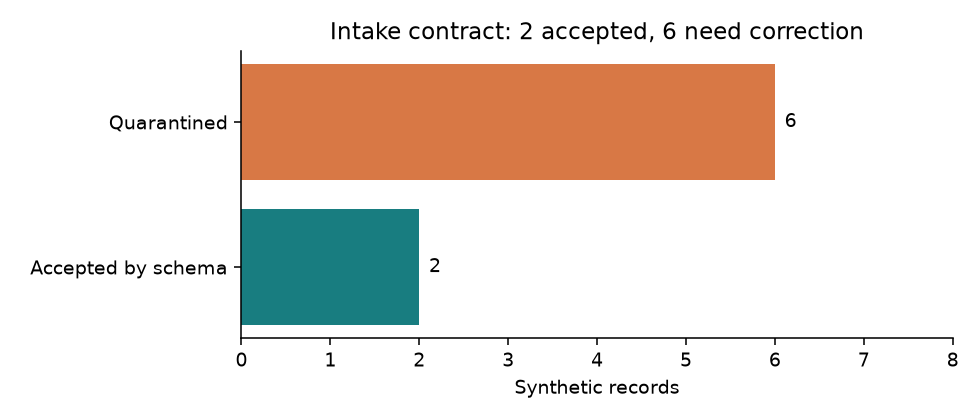

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
counts = [len(accepted), len(rejected)]
bars = ax.barh(["Accepted by schema", "Quarantined"], counts, color=["#187D80", "#D87845"])
ax.bar_label(bars, padding=5)
ax.set(xlim=(0, 8), xlabel="Synthetic records", title="Intake contract: 2 accepted, 6 need correction")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "validation_outcome.png", dpi=140)
from IPython.display import Image
display(Image(filename=str(OUT / "validation_outcome.png")))
plt.close(fig)

## 7. Serialize, round-trip and describe the API
`model_dump()` returns Python values (including UUID/datetime objects). `model_dump(mode="json")` returns JSON-compatible values. `model_dump_json()` returns a JSON string. `model_validate_json()` validates that string on input.

JSON Schema describes field structure and constraints for API tooling. Arbitrary Python model-validator logic, such as the consent chronology rule, is **not fully represented** by the generated schema; the server still needs to run validation.

In [7]:
python_data = first.model_dump()
json_data = first.model_dump(mode="json")
wire = first.model_dump_json(indent=2)
assert Lead.model_validate_json(wire) == first
assert isinstance(json_data["business_id"], str)
print("Python business ID type:", type(python_data["business_id"]).__name__)
print("JSON business ID type:", type(json_data["business_id"]).__name__)
schema = Lead.model_json_schema()
print("Required fields:", schema["required"])
print("Unknown fields allowed:", schema["additionalProperties"])
(OUT / "lead.schema.json").write_text(json.dumps(schema, indent=2), encoding="utf-8")
(OUT / "accepted.synthetic.json").write_text(json.dumps([x.model_dump(mode="json") for x in accepted], indent=2), encoding="utf-8")

Python business ID type: UUID
JSON business ID type: str
Required fields: ['lead_id', 'business_id', 'contact', 'service', 'received_at']
Unknown fields allowed: False


707

## 8. Validate a collection or a tagged event
`TypeAdapter` validates a type without declaring a wrapper model. A discriminated union selects the right event model from a literal tag, avoiding ambiguous interpretation. Unknown event types are rejected. These examples model data only; an appointment event would still require verification against the real booking provider.

In [8]:
ids = TypeAdapter(list[int]).validate_python(["1", "2"])
assert ids == [1, 2]

class InquiryEvent(BaseModel):
    model_config = ConfigDict(extra="forbid")
    kind: Literal["inquiry"]
    lead_id: int = Field(gt=0)

class OptOutEvent(BaseModel):
    model_config = ConfigDict(extra="forbid")
    kind: Literal["opt_out"]
    lead_id: int = Field(gt=0)
    reason: str = Field(min_length=1)

Event = Annotated[InquiryEvent | OptOutEvent, Field(discriminator="kind")]
event_adapter = TypeAdapter(Event)
print(event_adapter.validate_python({"kind": "opt_out", "lead_id": 1, "reason": "Customer request"}))
try:
    event_adapter.validate_python({"kind": "unknown", "lead_id": 1})
except ValidationError as error:
    print("Unknown tag:", error.errors()[0]["type"])

kind='opt_out' lead_id=1 reason='Customer request'
Unknown tag: union_tag_invalid


## 9. Validate an ordinary Python function
`@validate_call` checks annotated arguments before executing a function. `validate_return=True` also checks its result; return validation is off by default. This example uses strict, nonnegative integers and integer cents to avoid floating-point currency arithmetic.

The three-cent value below is an arbitrary teaching assumption, not a provider quote. The function only computes an estimate.

In [9]:
display(Code(inspect.getsource(estimate_batch_cost), language="python"))
assert estimate_batch_cost(4, 3) == 12
print("Illustrative estimate:", estimate_batch_cost(4, 3), "cents")
try:
    estimate_batch_cost("4", 3)
except ValidationError as error:
    print("String count rejected:", error.errors()[0]["type"])

@validate_call(validate_return=True)
def broken_total() -> int:
    return "not a number"

try:
    broken_total()
except ValidationError:
    print("Invalid return value rejected")

@validate_call(config=ConfigDict(strict=True), validate_return=True)
def estimate_batch_cost(
    messages: Annotated[int, Field(ge=0)],
    cents_per_message: Annotated[int, Field(ge=0)],
) -> int:
    """Illustrative arithmetic, not provider pricing or a send operation."""
    return messages * cents_per_message

Illustrative estimate: 12 cents
String count rejected: int_type
Invalid return value rejected


## 10. Validation is a boundary, not permanent protection
Models are normally mutable, and assignments are not validated by default. `validate_assignment=True` checks attribute replacement. It does not monitor every in-place mutation of a nested list. For proposed changes, validate a complete new payload before replacing the stored record.

Also avoid `model_construct()` and `model_copy(update=...)` for untrusted changes: those operations can bypass validation. Neither schema validation nor frozen models replace database constraints or authorization.

In [10]:
class Quantity(BaseModel):
    model_config = ConfigDict(validate_assignment=True)
    value: int = Field(ge=0)

quantity = Quantity(value=2)
try:
    quantity.value = -1
except ValidationError:
    print("Invalid assignment rejected")
assert quantity.value == 2
other = Lead.model_validate(records[1])
first.tags.append("reviewed")
assert other.tags == []
print("Independent tag defaults:", first.tags, other.tags)

Invalid assignment rejected
Independent tag defaults: ['reviewed'] []


## 11. Turn validation evidence into a decision
A schema-valid record is eligible for the **next review stage**, not automatically approved for outreach. The one record with declared marketing consent still needs current preference, identity, authorization and duplicate checks. No messages are sent.

The intake owner should correct rejected rows at their source and rerun validation. Keep the contract stable and test changes before accepting new service names or changing conversion rules.

In [11]:
declared_consent = sum(x.marketing_consent for x in accepted)
report = {"input_records": len(records), "schema_accepted": len(accepted),
          "quarantined": len(rejected), "accepted_with_declared_marketing_consent": declared_consent,
          "messages_sent": 0}
assert declared_consent == 1
assert report["messages_sent"] == 0
(OUT / "validation_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
display(Markdown(f"**Decision:** move {len(accepted)} records to downstream review; return {len(rejected)} for correction. **No outreach is authorized by this notebook.**"))
print(json.dumps(report, indent=2))

**Decision:** move 2 records to downstream review; return 6 for correction. **No outreach is authorized by this notebook.**

{
  "input_records": 8,
  "schema_accepted": 2,
  "quarantined": 6,
  "accepted_with_declared_marketing_consent": 1,
  "messages_sent": 0
}


## 12. Run, test and extend
From the repository root:

```bash
python -m pip install -r requirements.txt
python case_study.py
python -m pytest -q
python execute_notebook.py
```

The last command executes this notebook using the same Python environment and saves its outputs. Open the committed notebook on GitHub to read the rendered result without installing anything. Generated synthetic exports go to `case_study_outputs/` and are ignored by Git.

**Practice:** add a bounded vehicle-year field; compare strict and permissive integer inputs; add tests for whitespace-only names; introduce another event type; document which checks require a database instead of Pydantic.

**What this case establishes:** types and constraints are executable contracts; conversion choices need explicit policy; rejected records remain accountable; serializing a model does not verify the truth of its contents.

### References
- [Pydantic models](https://docs.pydantic.dev/latest/concepts/models/)
- [Strict mode](https://docs.pydantic.dev/latest/concepts/strict_mode/)
- [Validators](https://docs.pydantic.dev/latest/concepts/validators/)
- [TypeAdapter](https://docs.pydantic.dev/latest/concepts/type_adapter/)
- [Validation decorator](https://docs.pydantic.dev/latest/concepts/validation_decorator/)
- [Style reference: Decision Storytelling advanced case study](https://github.com/JCZY999/Decision-storytelling/blob/main/decision-storytelling-advanced-case-study.ipynb)